## Visualizes BayesWave reconstruction results across multiple experiments

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from gwpy.timeseries import TimeSeries
from gwpy.frequencyseries import FrequencySeries

import seaborn as sns
sns.set(style='whitegrid', context='paper', font_scale=1.8)

/home/x-ctirapongpra/.local/lib/python3.9/site-packages/gwpy/time/__init__.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  from lal import LIGOTimeGPS


In [2]:
def load_time_domain_data(filepath):
    """Load time domain data from BayesWave output files.
    
    Parameters
    ----------
    filepath : str or Path
        Path to the data file
    
    Returns
    -------
    np.ndarray
        Array with shape (N, 2) containing [time, strain] columns
    """
    with open(filepath, 'r') as f:
        for line in f:
            if line.strip() == '---------------':
                break
        next(f)
        data = []
        for line in f:
            parts = line.strip().split()
            if len(parts) == 2:
                data.append([float(parts[0]), float(parts[1])])
    
    return np.array(data)


def load_psd_data(filepath):
    """Load power spectral density data from BayesWave output files.
    
    Parameters
    ----------
    filepath : str or Path
        Path to the PSD data file
    
    Returns
    -------
    np.ndarray
        Array with shape (N, 2) containing [frequency, PSD] columns
    """
    with open(filepath, 'r') as f:
        for line in f:
            if line.strip() == '---------------':
                break
        next(f)
        data = []
        for line in f:
            parts = line.strip().split()
            if len(parts) == 2:
                data.append([float(parts[0]), float(parts[1])])
    
    return np.array(data)

In [3]:
# Experiment parameters
durations = ['04s', '08s', '16s', '32s']
amplitudes = ['1.25', '2.50', '5.00']
base_path = Path('/anvil/scratch/x-ctirapongpra/gw-collapsar/Frames')

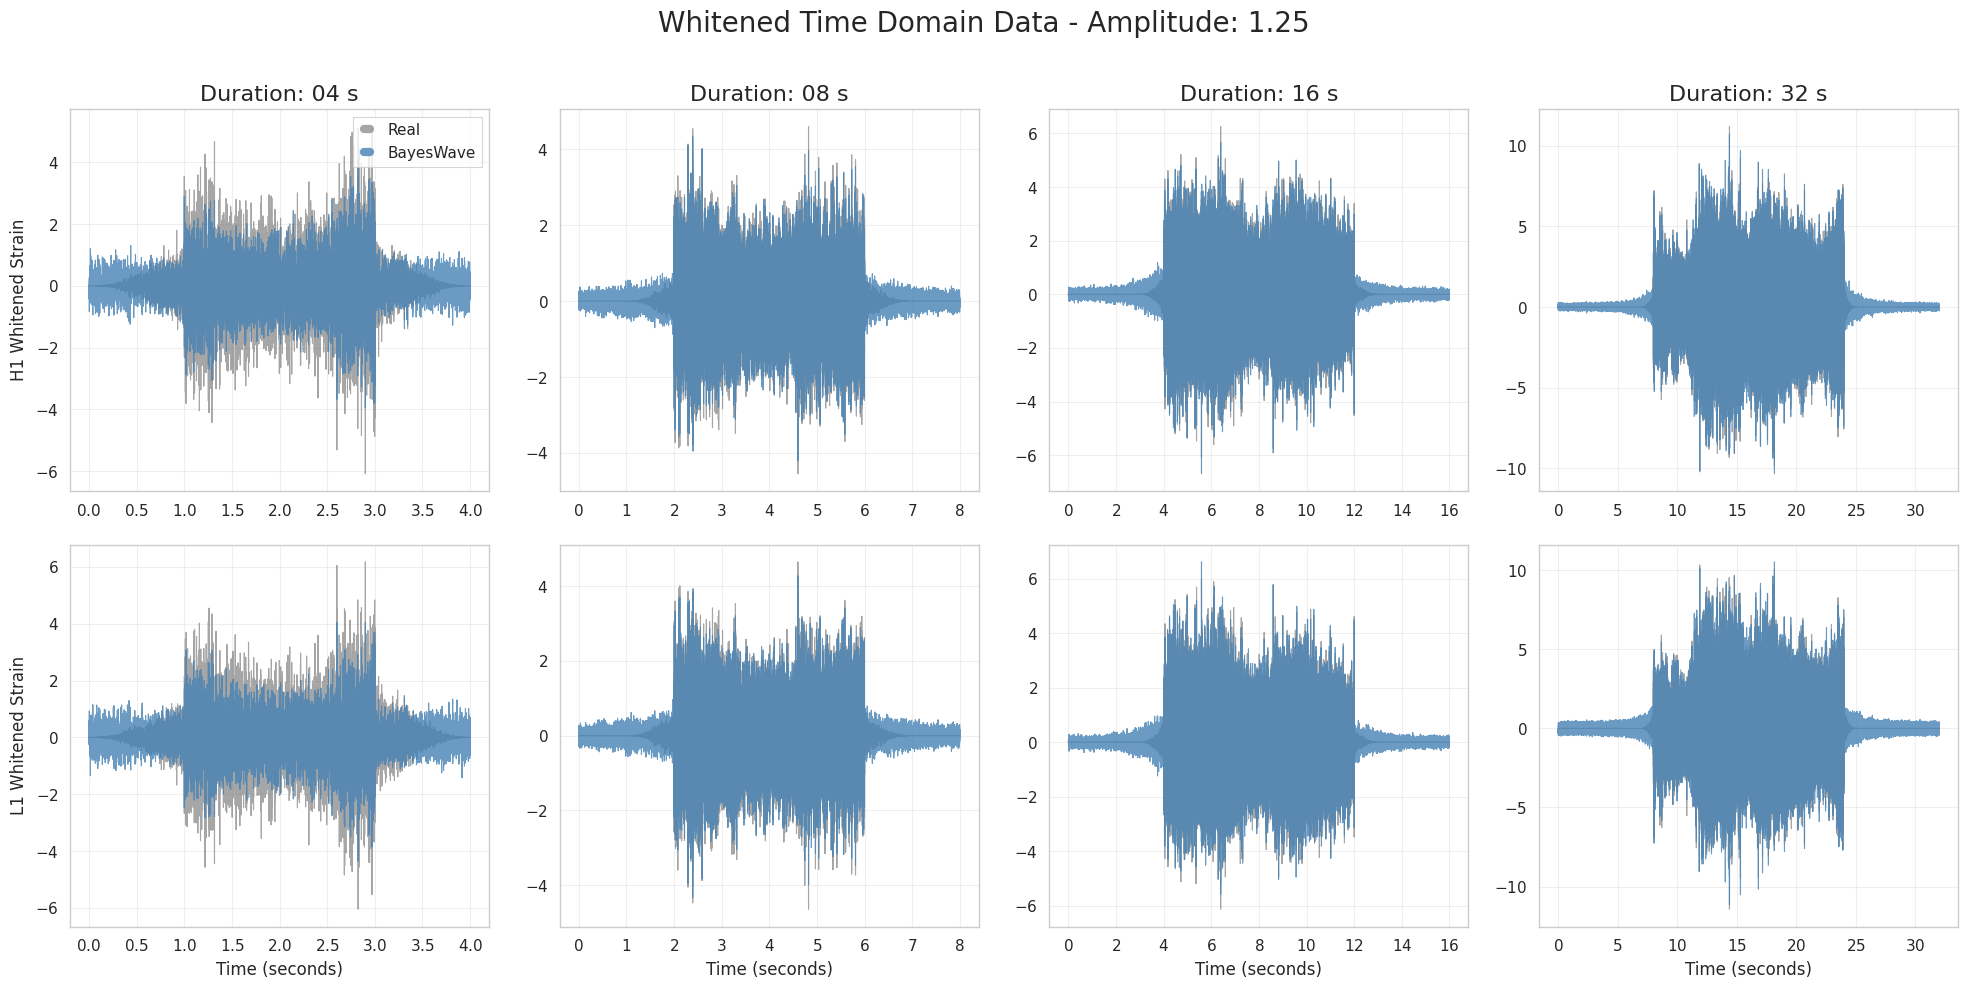

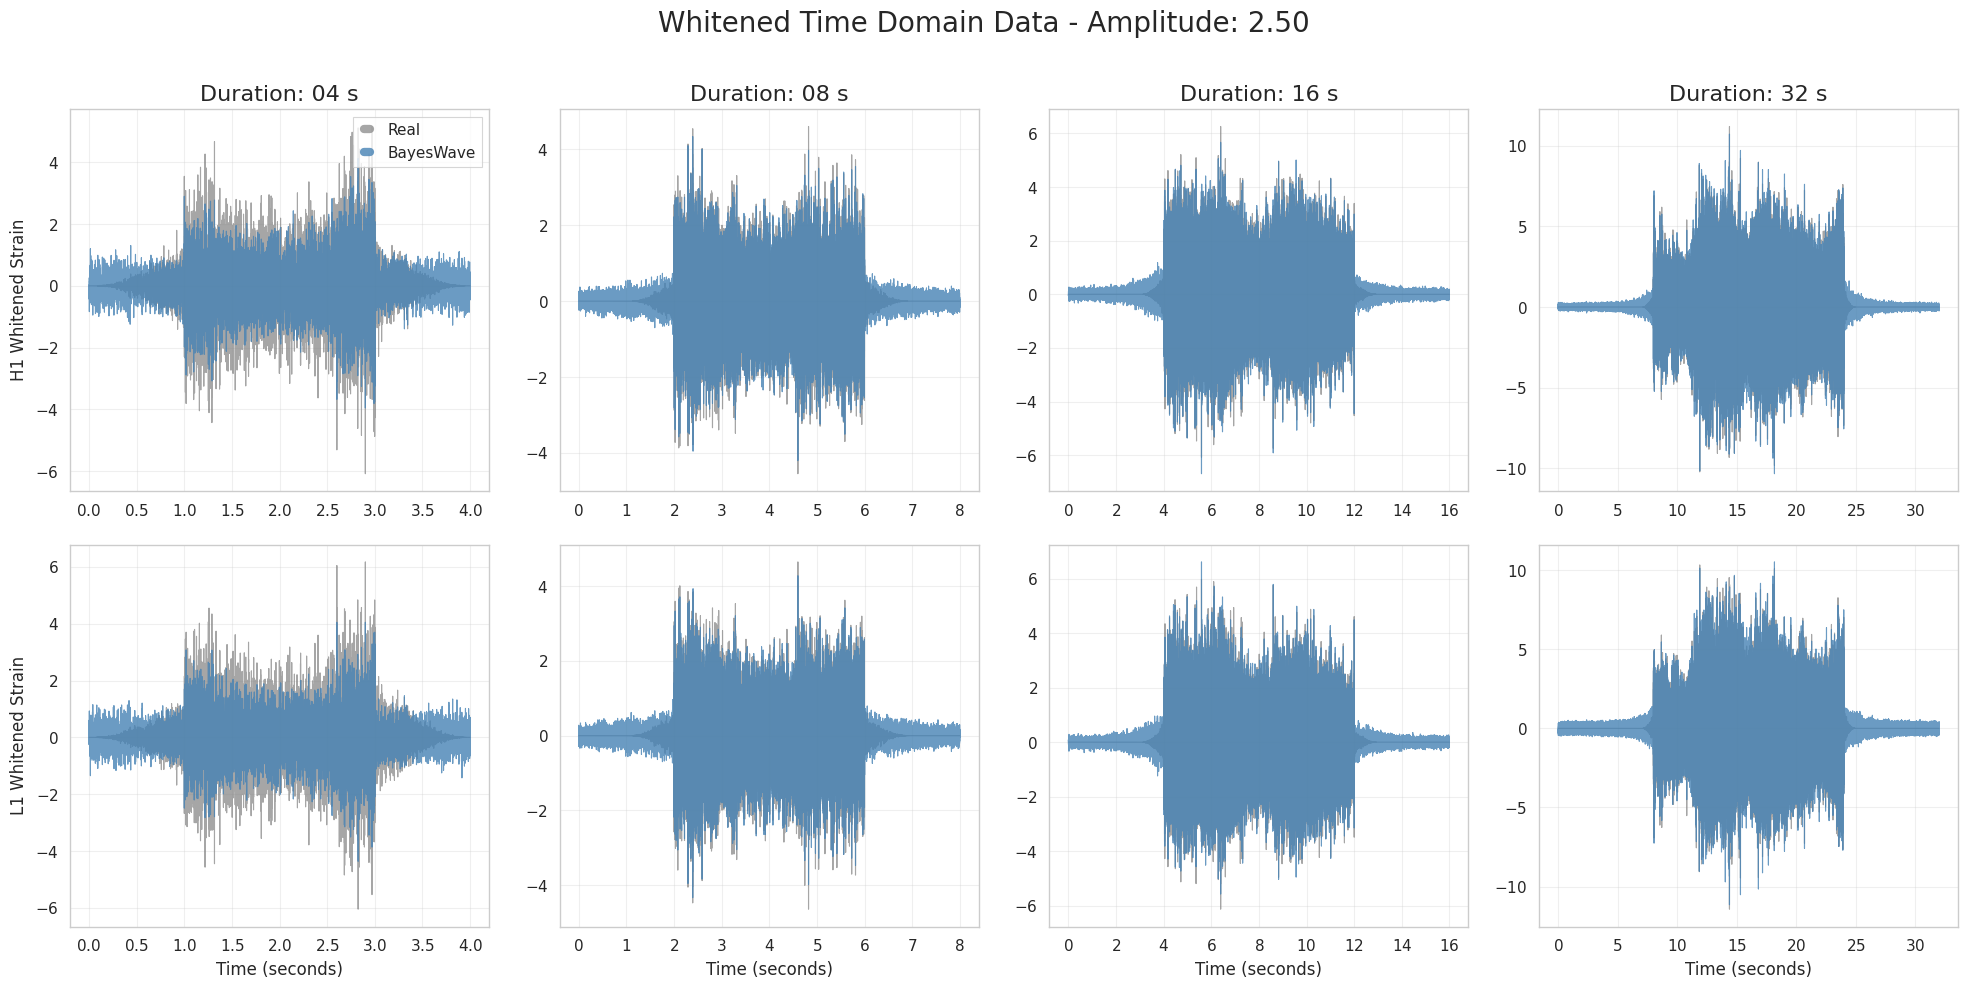

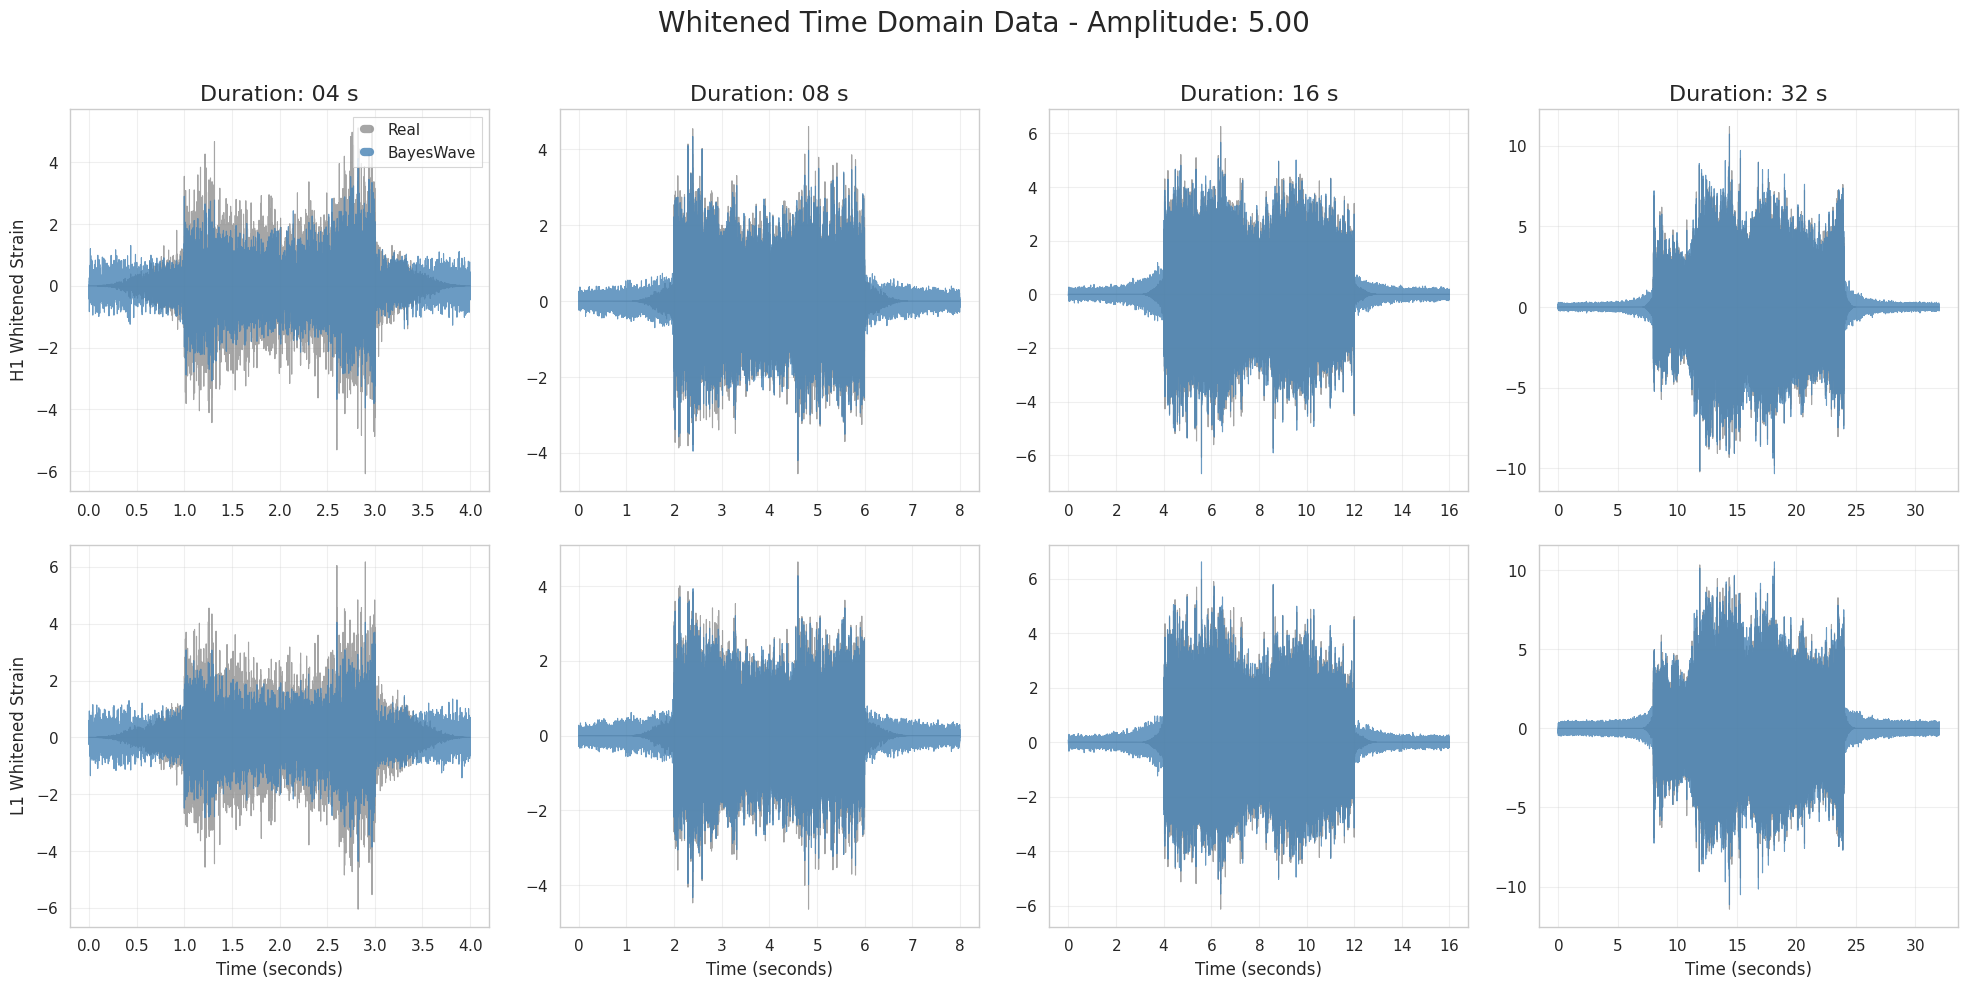

In [4]:
# Plot whitened data: BayesWave reconstruction vs real strain
for amp in amplitudes:
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    
    for col_idx, dur in enumerate(durations):
        exp_dir = base_path / f'dur_{dur}_amp_{amp}'
        data_dir = exp_dir / 'bayeswave_output_0' / 'data'
        
        # Load BayesWave whitened reconstruction
        h1_whitened = load_time_domain_data(data_dir / 'whitened_time_domain_data_H1.dat')
        l1_whitened = load_time_domain_data(data_dir / 'whitened_time_domain_data_L1.dat')
        
        # Load BayesWave PSD and convert to ASD
        h1_psd_data = load_psd_data(data_dir / 'noise_psd_H1.dat')
        l1_psd_data = load_psd_data(data_dir / 'noise_psd_L1.dat')
        
        h1_asd = FrequencySeries(
            np.sqrt(h1_psd_data[:, 1]),
            frequencies=h1_psd_data[:, 0],
            name='H1 ASD'
        )
        l1_asd = FrequencySeries(
            np.sqrt(l1_psd_data[:, 1]),
            frequencies=l1_psd_data[:, 0],
            name='L1 ASD'
        )
        
        # Load and whiten original frame data
        h1_frame = TimeSeries.read(exp_dir / 'H1.gwf', 'H1:GW-H')
        l1_frame = TimeSeries.read(exp_dir / 'L1.gwf', 'L1:GW-L')
        
        h1_frame_whitened = h1_frame.whiten(asd=h1_asd)
        l1_frame_whitened = l1_frame.whiten(asd=l1_asd)
        
        # Align time to start at zero
        h1_time_aligned = h1_frame_whitened.times.value - h1_frame_whitened.times.value[0]
        l1_time_aligned = l1_frame_whitened.times.value - l1_frame_whitened.times.value[0]
        
        # Plot H1
        ax_h1 = axes[0, col_idx]
        ax_h1.plot(h1_time_aligned, h1_frame_whitened.value, '-', 
                   color='gray', linewidth=0.8, label='Real', alpha=0.7)
        ax_h1.plot(h1_whitened[:, 0], h1_whitened[:, 1], '-', 
                   color='steelblue', linewidth=0.8, label='BayesWave', alpha=0.8)
        
        ax_h1.set_title(f'Duration: {dur.replace("s", " s")}', fontsize=16)
        if col_idx == 0:
            ax_h1.set_ylabel('H1 Whitened Strain', fontsize=12)
            ax_h1.legend(loc='upper right', fontsize=11)
        ax_h1.grid(True, alpha=0.3)
        ax_h1.tick_params(axis='both', which='major', labelsize=11)
        
        # Plot L1
        ax_l1 = axes[1, col_idx]
        ax_l1.plot(l1_time_aligned, l1_frame_whitened.value, '-', 
                   color='gray', linewidth=0.8, label='Real', alpha=0.7)
        ax_l1.plot(l1_whitened[:, 0], l1_whitened[:, 1], '-', 
                   color='steelblue', linewidth=0.8, label='BayesWave', alpha=0.8)
        
        if col_idx == 0:
            ax_l1.set_ylabel('L1 Whitened Strain', fontsize=12)
        ax_l1.set_xlabel('Time (seconds)', fontsize=12)
        ax_l1.grid(True, alpha=0.3)
        ax_l1.tick_params(axis='both', which='major', labelsize=11)
    
    fig.suptitle(f'Whitened Time Domain Data - Amplitude: {amp}', fontsize=20, y=0.995)
    plt.tight_layout()
    plt.show()

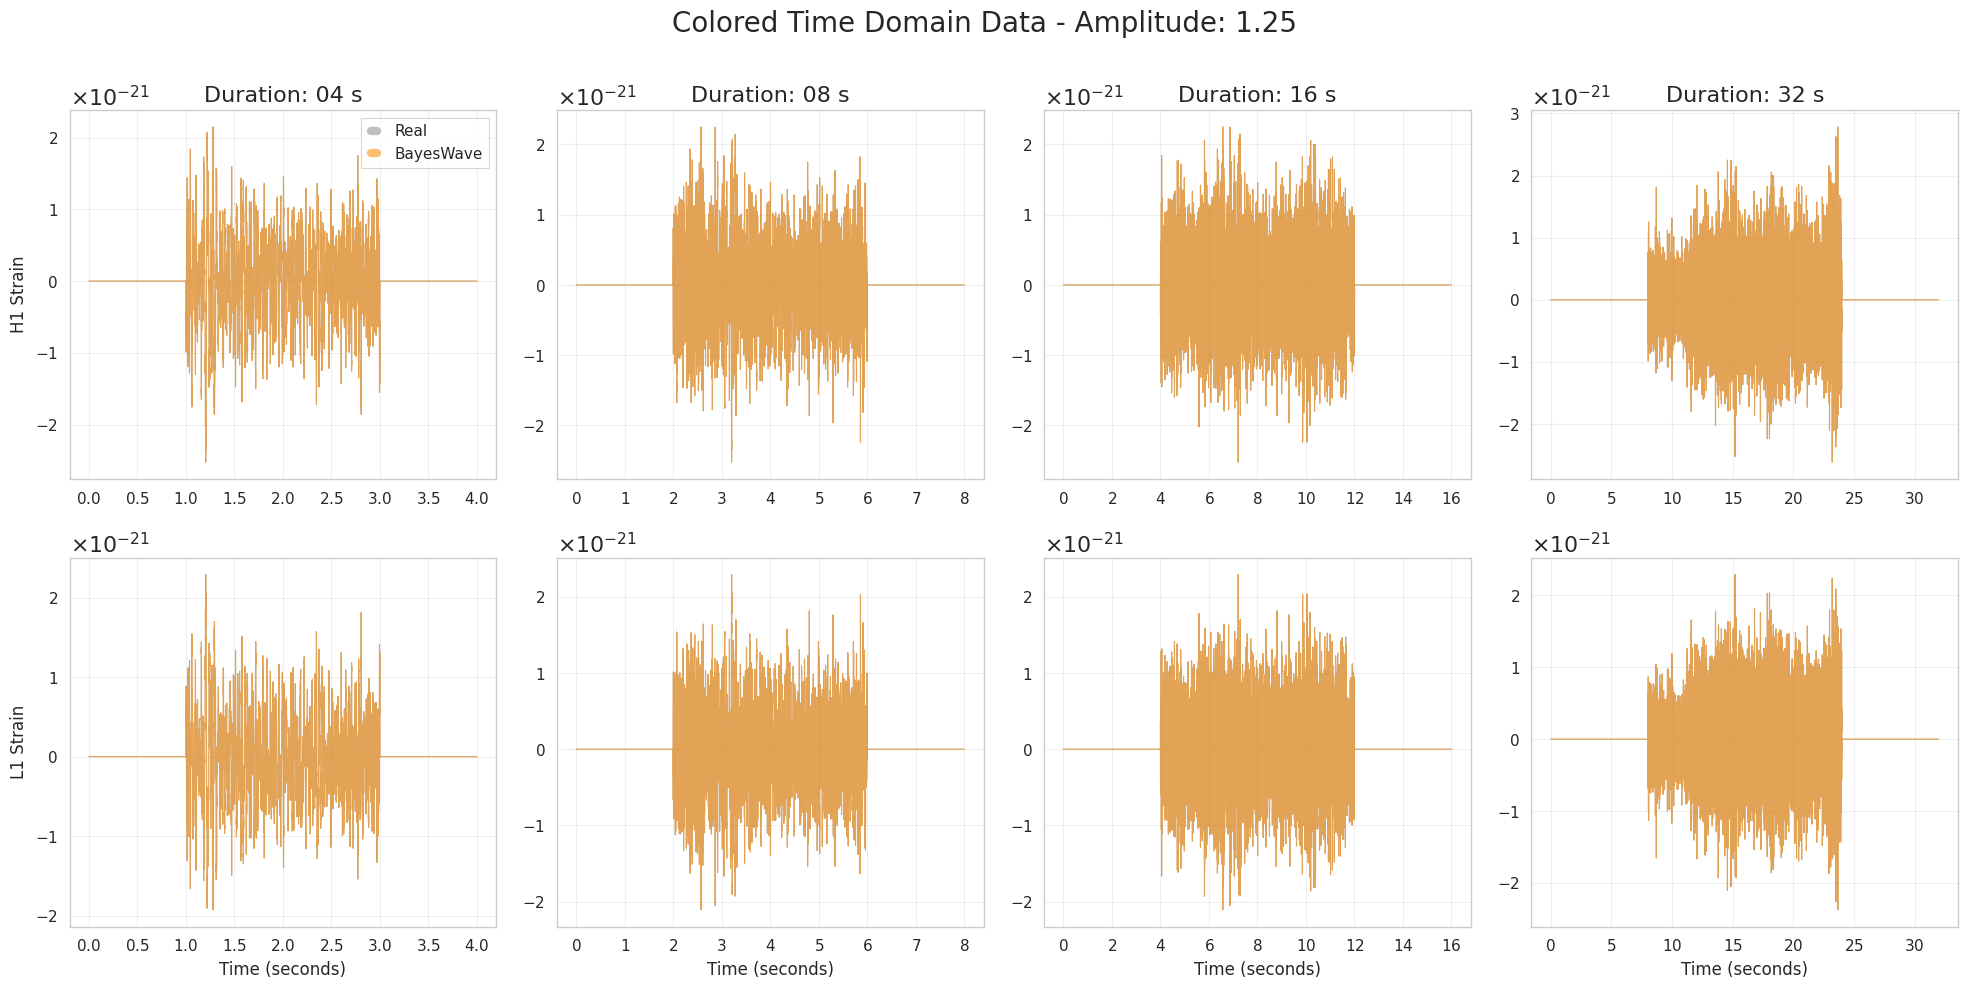

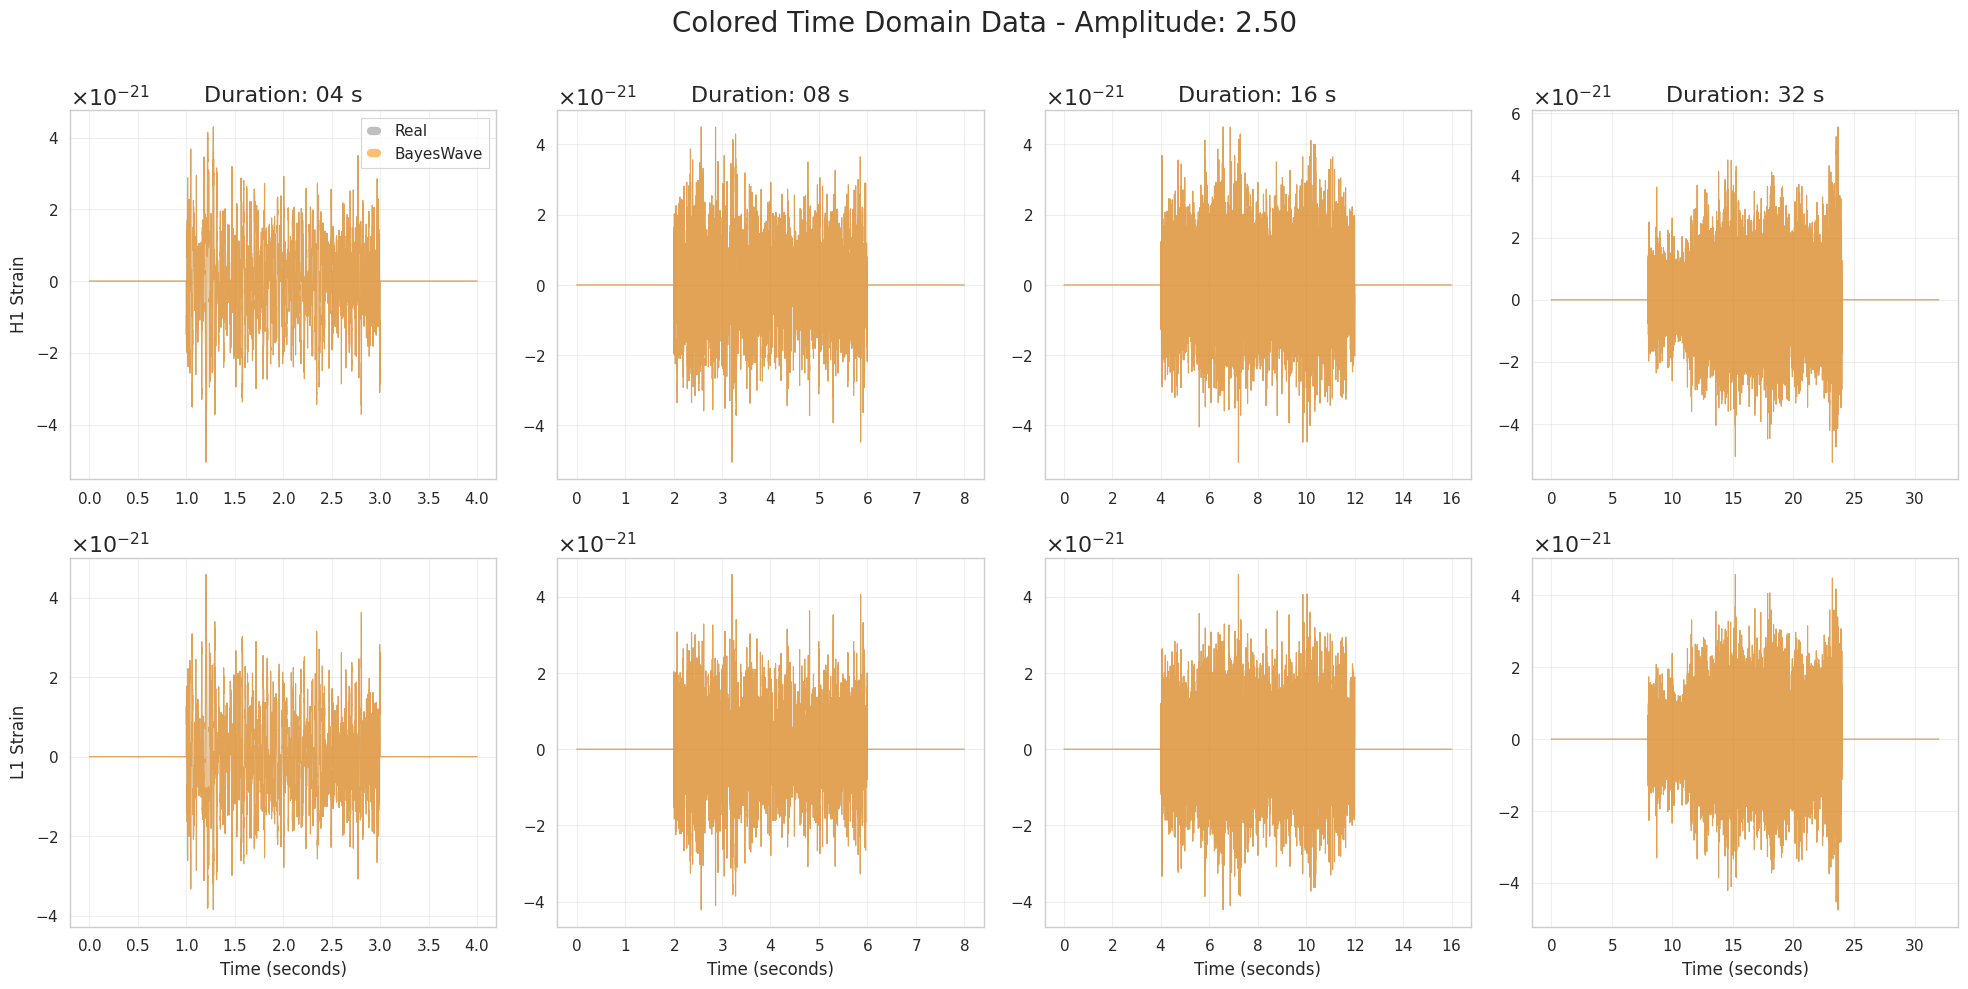

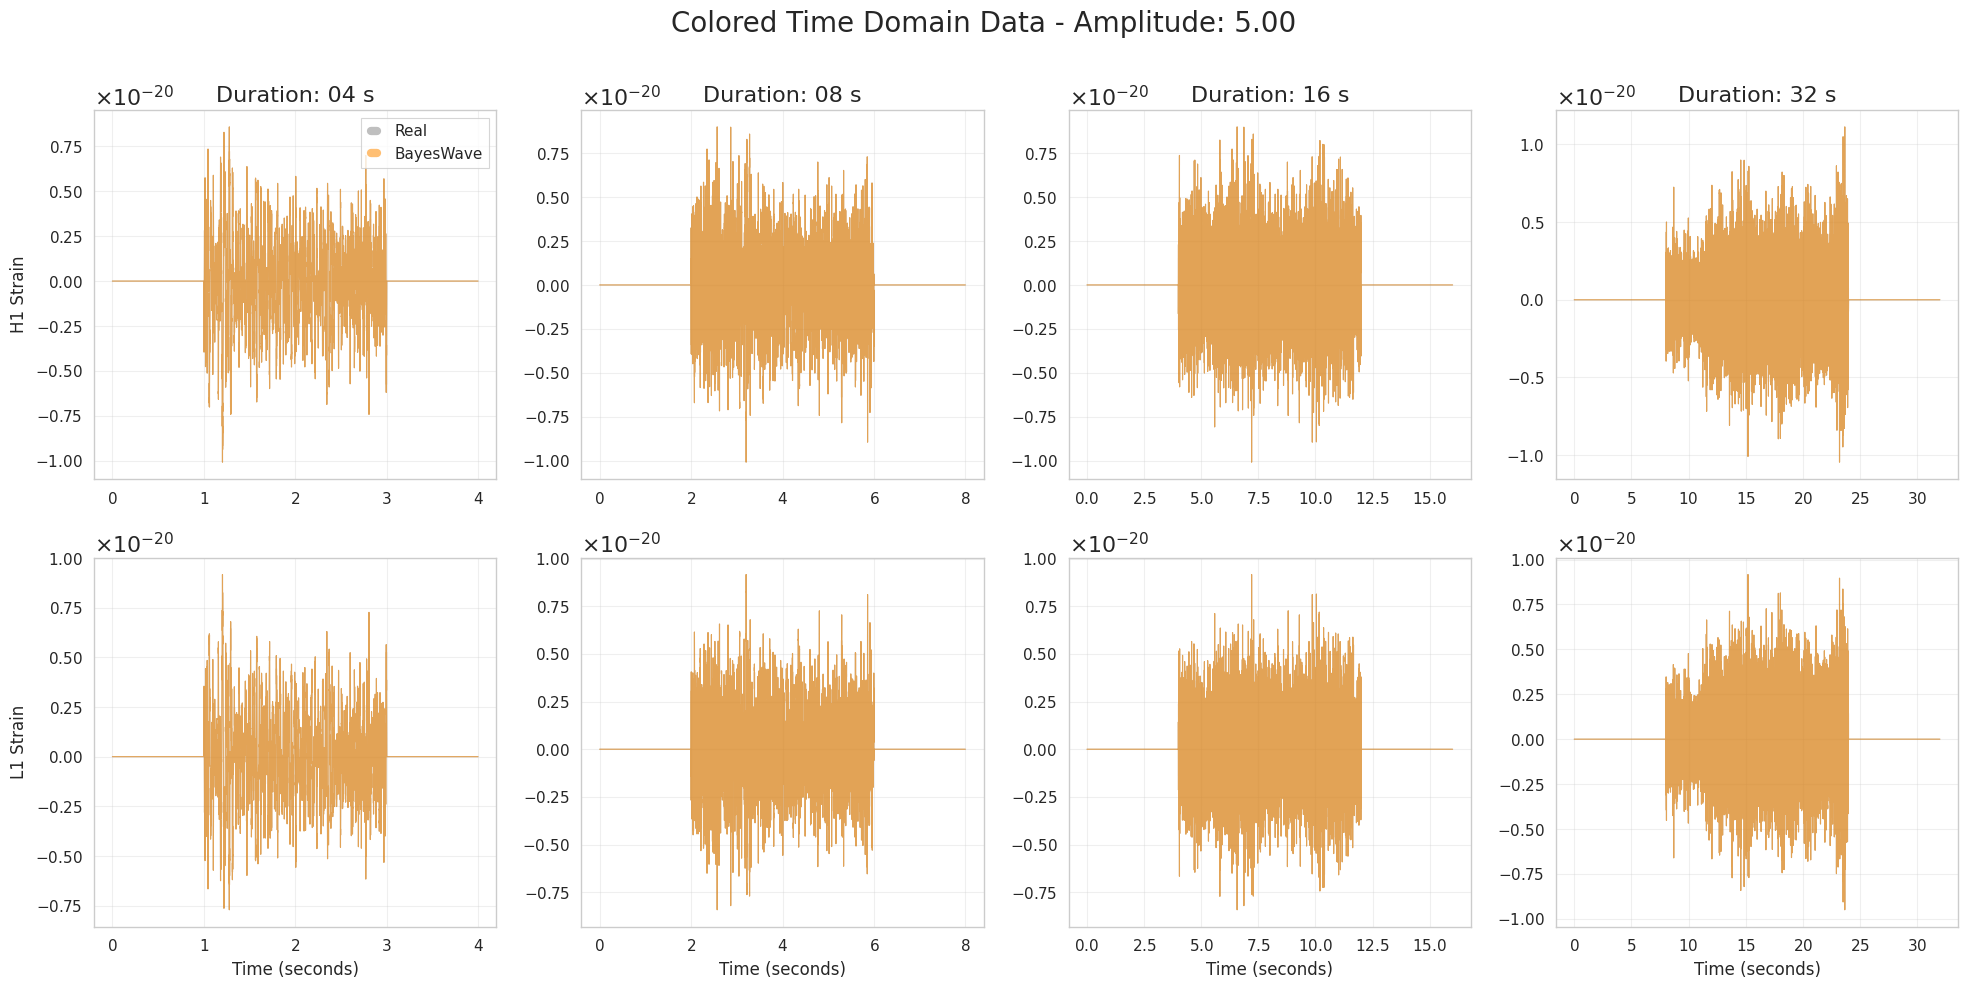

In [5]:
# Plot colored data: BayesWave reconstruction vs real strain
for amp in amplitudes:
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    
    for col_idx, dur in enumerate(durations):
        exp_dir = base_path / f'dur_{dur}_amp_{amp}'
        data_dir = exp_dir / 'bayeswave_output_0' / 'data'
        
        # Load BayesWave colored reconstruction
        h1_colored = load_time_domain_data(data_dir / 'colored_time_domain_data_H1.dat')
        l1_colored = load_time_domain_data(data_dir / 'colored_time_domain_data_L1.dat')
        
        # Load original frame data
        h1_frame = TimeSeries.read(exp_dir / 'H1.gwf', 'H1:GW-H')
        l1_frame = TimeSeries.read(exp_dir / 'L1.gwf', 'L1:GW-L')
        
        # Align time to start at zero
        h1_time_aligned = h1_frame.times.value - h1_frame.times.value[0]
        l1_time_aligned = l1_frame.times.value - l1_frame.times.value[0]
        
        # Plot H1
        ax_h1 = axes[0, col_idx]
        ax_h1.plot(h1_time_aligned, h1_frame.value, '-', 
                   color='gray', linewidth=0.8, label='Real', alpha=0.5)
        ax_h1.plot(h1_colored[:, 0], h1_colored[:, 1], '-', 
                   color='darkorange', linewidth=0.8, label='BayesWave', alpha=0.55)
        
        ax_h1.set_title(f'Duration: {dur.replace("s", " s")}', fontsize=16)
        if col_idx == 0:
            ax_h1.set_ylabel('H1 Strain', fontsize=12)
            ax_h1.legend(loc='upper right', fontsize=11)
        ax_h1.grid(True, alpha=0.3)
        ax_h1.tick_params(axis='both', which='major', labelsize=11)
        
        # Plot L1
        ax_l1 = axes[1, col_idx]
        ax_l1.plot(l1_time_aligned, l1_frame.value, '-', 
                   color='gray', linewidth=0.8, label='Real', alpha=0.5)
        ax_l1.plot(l1_colored[:, 0], l1_colored[:, 1], '-', 
                   color='darkorange', linewidth=0.8, label='BayesWave', alpha=0.55)
        
        if col_idx == 0:
            ax_l1.set_ylabel('L1 Strain', fontsize=12)
        ax_l1.set_xlabel('Time (seconds)', fontsize=12)
        ax_l1.grid(True, alpha=0.3)
        ax_l1.tick_params(axis='both', which='major', labelsize=11)
    
    fig.suptitle(f'Colored Time Domain Data - Amplitude: {amp}', fontsize=20, y=0.995)
    plt.tight_layout()
    plt.show()